Process Rates

In [3]:
import pandas as pd
file_list = ['/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09159_BS_mih1.0-4.0_probs99ALL.txt',
            '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09159_PS_mih1.0-4.0_probs99ALL.txt',
            '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09174_BS_probs99ALL.txt',
            '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09174_PS_probs99ALL.txt']
all_events = pd.DataFrame()

for f,file in enumerate(file_list):
    print(file)
    #read file and calculate mean probability for each event stored as a row( event_id, prob0....prob999)
    df = pd.read_csv(file, sep=',' ,header= None, skiprows=1)
    # append to all_events
    all_events = pd.concat([all_events,df],axis=0)
    del df
#rename first column to ID
all_events.rename(columns={0: 'ID'}, inplace=True)    
#drop duplicates
all_events.drop_duplicates(subset='ID', keep='first', inplace=True)

#read event info file
event_info = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/event_rates_mean53550.csv',sep=',')
all_events = all_events.set_index('ID').reindex(event_info['eve_id']).reset_index()
#save to file
all_events.to_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/all_eventsBS_PS53550_ratesALL.txt', index=False)

/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09159_BS_mih1.0-4.0_probs99ALL.txt
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09159_PS_mih1.0-4.0_probs99ALL.txt
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09174_BS_probs99ALL.txt
/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/eve_rate/med09174_PS_probs99ALL.txt


P84 20 Hazard Map for EGU or PhD Defense Slides

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['529']   
columnname = str(38)
mask_size = '892'
train_size = list_size[0]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

grid_CT_P1 = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2_topo_test.nc',engine='netcdf4')
temp = grid_CT_P1['r2topo']
temp = temp.where(temp>0,0)
grid_CT_P1['r2topo'] = temp

# Plot grid
fig = pygmt.Figure()

with fig.subplot(
        nrows=1,
        ncols=1,
        subsize = ["8","20c"],
        sharey = True,
        frame = ["ag"],
        clearance  = "w4.5c",
        ):
    with fig.set_panel(0):
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tEx. Prob(20 cm)"])
        fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2only.cpt'
        cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background='white')
        idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_1658_PSHalf.txt', sep=",")
        ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')
        #replace 0 with nan
        ex_rate[ex_rate == 0] = np.nan
        fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,0],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
        grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate[:,0], spacing='1s', region=[xmin,xmax,ymin,ymax])
        # fig.grdimage(grid_rate, cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"])
        fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c')
        fig.colorbar(frame=["x+lprobability"], position="JML+o4.5c/-2.5c+w8c/0.5c+m", log = True)  
fig.show()

#save as csv 
table = pd.DataFrame({'lon': idx_val['lon'], 'lat': idx_val['lat'], 'ex_rate': ex_rate[:,0]})
table.to_csv(f'//mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/PTHA/ex_rate_{train_size}.csv', index=False)

SIS hazard

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
reg = 'CT'
train_size = 1658
# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values


dthresholds = np.array([
    1.000e-02, 5.000e-02, 1.000e-01, 2.000e-01,
    3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
    1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
    3.600e+00, 4.320e+00, 5.180e+00, 6.220e+00,
    7.460e+00, 8.950e+00, 1.074e+01, 1.289e+01,
    1.547e+01, 1.856e+01, 2.227e+01
]) * 100

def interpolate_ex_rate(ex_rate_table, thresholds, exact_depth):
    """
    Interpolate exceedance rates for a given exact depth in cm.
    If depth exists, returns that column. Else interpolates between two threshold columns.
    """
    # ✅ Ensure thresholds is a NumPy array
    thresholds = np.array(thresholds)

    print('thresholds:', thresholds)
    print('exact_depth:', exact_depth)

    # Case 1: Exact match
    if exact_depth in thresholds:
        col = np.where(thresholds == exact_depth)[0][0]
        print(f"Exact depth {exact_depth} cm found in column {col}. Returning ex_rate for that depth.")
        return ex_rate_table[:, col]

    # Case 2: Interpolation between nearest thresholds
    else:
        # Ensure the depth is within range
        if exact_depth < thresholds.min() or exact_depth > thresholds.max():
            raise ValueError(f"Depth {exact_depth} cm is outside threshold range ({thresholds.min()}–{thresholds.max()}).")

        lower_col = np.where(thresholds < exact_depth)[0][-1]
        upper_col = np.where(thresholds > exact_depth)[0][0]

        print(f"Exact depth {exact_depth} cm not found. Interpolating between {thresholds[lower_col]} and {thresholds[upper_col]} cm.")

        lower_val = ex_rate_table[:, lower_col]
        upper_val = ex_rate_table[:, upper_col]

        # Linear interpolation
        x0, x1 = thresholds[lower_col], thresholds[upper_col]
        interpolated_ex_rate = lower_val + (exact_depth - x0) * (upper_val - lower_val) / (x1 - x0)

        print('Non-zero sizes:', np.count_nonzero(lower_val), np.count_nonzero(upper_val))
        print('Final non-zero size:', np.count_nonzero(interpolated_ex_rate))

        return interpolated_ex_rate


#flattent the grid to 1D array to get x,y,z
grid_CT_flat = grid_CT.stack(points=['y', 'x'])
zero_mask = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/zero_mask_CT_892.npy')
zero_mask_flat = zero_mask.flatten()
np.count_nonzero(~zero_mask_flat)

#convert to pandas dataframe
grid_CT_flat = grid_CT_flat.to_dataframe()

fig = pygmt.Figure()

with fig.subplot(
        nrows=1,
        ncols=1,
        subsize = ["8","20c"],
        sharey = True,
        frame = ["ag"],
        clearance  = "w4.5c",
        ):
    with fig.set_panel(0):
        
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
        fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/JGR/plots/extra/hot.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        ex_rate_table = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/SIS/SIS_MAPS/catania/3000/hc_mean.npy')
        ex_rate = interpolate_ex_rate(ex_rate_table, dthresholds,500)
        ex_rate = np.reshape(ex_rate, (grid_CT.dims['y'], grid_CT.dims['x']))
        ex_rate = ex_rate.flatten()
        ex_rate = ex_rate[zero_mask_flat==False]
        idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
        #drop rows with 0 ex_rate
        idx_val = idx_val.iloc[ex_rate > 0]
        ex_rate = ex_rate[ex_rate > 0]
        fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
        fig.colorbar(frame=["x+lprobability"], position="JML+o4.5c/-2.5c+w8c/0.5c+m", log = True)  
fig.show()


Compare all three simulatin vs emulation vs sis for Catania

In [19]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt
import geopandas as gpd
from shapely.geometry import Point

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['225', '529','892','1658','3454','7071']   
columnname = str(38)
mask_size = '892'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('../../../data/processed/CT_defbathy.nc',engine='netcdf4')
zero_mask = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/zero_mask_CT_892.npy')
zero_mask_flat = zero_mask.flatten()
np.count_nonzero(~zero_mask_flat)
shape_mask = gpd.read_file('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/extent/CT_PredictionArea.shp')

#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

Depth_list = [20,100,300,500,1000] 

dthresholds = [1.000e-02, 5.000e-02, 1.000e-01, 2.000e-01,
       3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
       1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
       3.600e+00, 4.320e+00, 5.180e+00, 6.220e+00,
       7.460e+00, 8.950e+00, 1.074e+01, 1.289e+01,
       1.547e+01, 1.856e+01, 2.227e+01]

#convert m thresholds to cm
dthresholds = np.array(dthresholds) * 100  # convert to cm
ex_rate_table = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/SIS/SIS_MAPS/catania/3000/hc_mean.npy')

def interpolate_ex_rate(ex_rate_table, thresholds, exact_depth):
    """
    Interpolate exceedance rates for a given exact depth.
    If depth exists, returns that column. Else interpolates between two threshold columns.
    """
    if exact_depth in thresholds:
        col = np.where(thresholds == exact_depth)[0][0]
        print(f"Exact depth {exact_depth} cm found in column {col}. Returning ex_rate for that depth.")
        return ex_rate_table[:, col]
    else:
        lower_col = np.where(thresholds < exact_depth)[0][-1]
        upper_col = np.where(thresholds > exact_depth)[0][0]
        
        print(f"Exact depth {exact_depth} cm not found. Interpolating between {thresholds[lower_col]} and {thresholds[upper_col]} cm.")

        lower_val = ex_rate_table[:, lower_col]
        upper_val = ex_rate_table[:, upper_col]

        # linear interpolation: y = y0 + (x - x0)*(y1 - y0)/(x1 - x0)
        x0, x1 = thresholds[lower_col], thresholds[upper_col]
        print('non zero size',np.count_nonzero(lower_val), np.count_nonzero(upper_val))
        interpolated_ex_rate = lower_val + (exact_depth - x0) * (upper_val - lower_val) / (x1 - x0)
        print('final non zero size',np.count_nonzero(interpolated_ex_rate))

        return interpolated_ex_rate

# ex_rate = interpolate_ex_rate(ex_rate_table, dthresholds, Depth_list[3])
for d,depth in enumerate(Depth_list):
    print(f"Processing depth: {depth} cm")
    # Plot grid
    fig = pygmt.Figure()

    with fig.subplot(
            nrows=3,
            ncols=1,
            subsize = ["8","17c"],
            sharey = True,
            frame = ["ag"],
            clearance  = "w4.5c",
            margins=["0.1c", "0.1c"]
            ): 
        with fig.set_panel(panel=[0,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy')[:,d]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="1p,darkgreen",fill=None,projection='M6c',frame = ["ag"])        
        with fig.set_panel(panel=[1,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')[:,d]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate_emu = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate_emu, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="1p,darkgreen",fill=None,projection='M6c',frame = ["ag"])       
        with fig.set_panel(panel=[2,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = interpolate_ex_rate(ex_rate_table, dthresholds,depth)
            ex_rate = np.reshape(ex_rate, (grid_CT.dims['y'], grid_CT.dims['x']))
            ex_rate = ex_rate.flatten()
            ex_rate = ex_rate[zero_mask_flat==False]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate_sis = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate_sis, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="1p,darkgreen",fill=None,projection='M6c',frame = ["ag"])
    #save
    savefile = f'./PTHA_{train_size}_{reg}_ProEx_{depth}.png'
    fig.savefig(savefile,dpi=300)
    # fig.show()

/tmp/ipykernel_651152/611917742.py:134: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ex_rate = np.reshape(ex_rate, (grid_CT.dims['y'], grid_CT.dims['x']))
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 7220
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.


Exact depth 1000 cm not found. Interpolating between 894.9999999999999 and 1074.0 cm.
non zero size 666743 647194
final non zero size 666743


Compare all three simulation vs emulation vs sis for Siracusa

In [26]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'SR'
list_size = ['228', '550' ,'961','1773','3669','6941']
columnname = str(54)
mask_size = '961'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_SR = xr.open_dataset('../../../data/processed/SR_defbathy.nc',engine='netcdf4')
zero_mask = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/zero_mask_SR_961.npy')
zero_mask_flat = zero_mask.flatten()
shape_mask = gpd.read_file('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/extent/SR_PredictionArea.shp')
#get lat long limits from the grid
ymin = grid_SR['y'].min().values
ymax = grid_SR['y'].max().values
xmin = grid_SR['x'].min().values
xmax = grid_SR['x'].max().values

Depth_list = [20,100,300,500,1000] 

dthresholds = [1.000e-02, 5.000e-02, 1.000e-01, 2.000e-01,
       3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
       1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
       3.600e+00, 4.320e+00, 5.180e+00, 6.220e+00,
       7.460e+00, 8.950e+00, 1.074e+01, 1.289e+01,
       1.547e+01, 1.856e+01, 2.227e+01]

#convert m thresholds to cm
dthresholds = np.array(dthresholds) * 100  # convert to cm
ex_rate_table = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/SIS/SIS_MAPS/siracusa/2370/hc_mean.npy')

def interpolate_ex_rate(ex_rate_table, thresholds, exact_depth):
    """
    Interpolate exceedance rates for a given exact depth.
    If depth exists, returns that column. Else interpolates between two threshold columns.
    """
    if exact_depth in thresholds:
        col = np.where(thresholds == exact_depth)[0][0]
        print(f"Exact depth {exact_depth} cm found in column {col}. Returning ex_rate for that depth.")
        return ex_rate_table[:, col]
    else:
        lower_col = np.where(thresholds < exact_depth)[0][-1]
        upper_col = np.where(thresholds > exact_depth)[0][0]
        
        print(f"Exact depth {exact_depth} cm not found. Interpolating between {thresholds[lower_col]} and {thresholds[upper_col]} cm.")

        lower_val = ex_rate_table[:, lower_col]
        upper_val = ex_rate_table[:, upper_col]

        # linear interpolation: y = y0 + (x - x0)*(y1 - y0)/(x1 - x0)
        x0, x1 = thresholds[lower_col], thresholds[upper_col]
        print('non zero size',np.count_nonzero(lower_val), np.count_nonzero(upper_val))
        interpolated_ex_rate = lower_val + (exact_depth - x0) * (upper_val - lower_val) / (x1 - x0)
        print('final non zero size',np.count_nonzero(interpolated_ex_rate))

        return interpolated_ex_rate


for d,depth in enumerate(Depth_list):
    # Plot grid
    fig = pygmt.Figure()
    with fig.subplot(
            nrows=3,
            ncols=1,
            subsize = ["6","5.5c"],
            sharey = True,
            frame = ["ag"],
            clearance  = "w4.5c",
            margins=["0.1c", "0.1c"]
            ): 
        with fig.set_panel(panel=[0,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy')[:,d]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="0.25p,darkgreen",fill=None,projection='M6c',frame = ["ag"])        
        
        with fig.set_panel(panel=[1,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')[:,d]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate_emu = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate_emu, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="0.25p,darkgreen",fill=None,projection='M6c',frame = ["ag"])   
        with fig.set_panel(panel=[2,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra//hot.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = interpolate_ex_rate(ex_rate_table, dthresholds,depth)
            ex_rate = np.reshape(ex_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
            ex_rate = ex_rate.flatten()
            ex_rate = ex_rate[zero_mask_flat==False]
            #drop rows with 0 ex_rate
            idx_val = idx_val.iloc[ex_rate > 0]
            ex_rate = ex_rate[ex_rate > 0]
            grid_rate_sis = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate, spacing='1s', region=[xmin,xmax,ymin,ymax])
            fig.grdimage(grid_rate_sis, cmap=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"],nan_transparent=True)
            # fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.5p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.5p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.5p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.5p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.plot(data=shape_mask,pen="0.25p,darkgreen",fill=None,projection='M6c',frame = ["ag"])
    #save
    savefile = f'./PTHA_{train_size}_{reg}_ProEx_{depth}.png'
    fig.savefig(savefile,dpi=300)
    # fig.show()

xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 221349
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 198127
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
/tmp/ipykernel_651152/3219471298.py:129: FutureWarni

Exact depth 20 cm found in column 3. Returning ex_rate for that depth.


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 202866
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 165127
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
/tmp/ipykernel_651152/3219471298.py:129: FutureWarni

Exact depth 100 cm found in column 7. Returning ex_rate for that depth.


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 120246
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 95070
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
/tmp/ipykernel_651152/3219471298.py:129: FutureWarnin

Exact depth 300 cm found in column 11. Returning ex_rate for that depth.


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 68467
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 59089
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
/tmp/ipykernel_651152/3219471298.py:129: FutureWarning

Exact depth 500 cm not found. Interpolating between 432.0 and 518.0 cm.
non zero size 455297 436159
final non zero size 455297


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 8100
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 8127
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.
/tmp/ipykernel_651152/3219471298.py:129: FutureWarning: 

Exact depth 1000 cm not found. Interpolating between 894.9999999999999 and 1074.0 cm.
non zero size 397947 388435
final non zero size 397947


Colormap

In [ ]:
# pygmt.makecpt(
#     cmap="polar",        # Diverging colormap, good for + / - errors
#     series=[-8, -1, 1], # Min, max, and interval
#     continuous=True,     # Smooth colour transitions
#     # output="./extra/log_error_ts.cpt",  # Save CPT file to disk
#     log=True
# )

Error Catania

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['225', '529','892','1658','3454','7071']   
columnname = str(38)
mask_size = '892'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('../../../data/processed/CT_defbathy.nc',engine='netcdf4')
zero_mask = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/zero_mask_CT_892.npy')
zero_mask_flat = zero_mask.flatten()
np.count_nonzero(~zero_mask_flat)
shape_mask = gpd.read_file('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/extent/CT_PredictionArea.shp')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

Depth_list = [20,100,300,500,1000] 

dthresholds = [1.000e-02, 5.000e-02, 1.000e-01, 2.000e-01,
       3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
       1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
       3.600e+00, 4.320e+00, 5.180e+00, 6.220e+00,
       7.460e+00, 8.950e+00, 1.074e+01, 1.289e+01,
       1.547e+01, 1.856e+01, 2.227e+01]

#convert m thresholds to cm
dthresholds = np.array(dthresholds) * 100  # convert to cm
ex_rate_table = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/SIS/SIS_MAPS/catania/3000/hc_mean.npy')

def interpolate_ex_rate(ex_rate_table, thresholds, exact_depth):
    """
    Interpolate exceedance rates for a given exact depth.
    If depth exists, returns that column. Else interpolates between two threshold columns.
    """
    if exact_depth in thresholds:
        col = np.where(thresholds == exact_depth)[0][0]
        print(f"Exact depth {exact_depth} cm found in column {col}. Returning ex_rate for that depth.")
        return ex_rate_table[:, col]
    else:
        lower_col = np.where(thresholds < exact_depth)[0][-1]
        upper_col = np.where(thresholds > exact_depth)[0][0]
        
        print(f"Exact depth {exact_depth} cm not found. Interpolating between {thresholds[lower_col]} and {thresholds[upper_col]} cm.")

        lower_val = ex_rate_table[:, lower_col]
        upper_val = ex_rate_table[:, upper_col]

        # linear interpolation: y = y0 + (x - x0)*(y1 - y0)/(x1 - x0)
        x0, x1 = thresholds[lower_col], thresholds[upper_col]
        print('non zero size',np.count_nonzero(lower_val), np.count_nonzero(upper_val))
        interpolated_ex_rate = lower_val + (exact_depth - x0) * (upper_val - lower_val) / (x1 - x0)
        print('final non zero size',np.count_nonzero(interpolated_ex_rate))

        return interpolated_ex_rate


for d, depth in enumerate(Depth_list):
    print(f"Processing depth: {depth} cm")

    
    # True, emulator, and SIS exceedance rates
    true_ref = np.load(
        f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy'
    )[:, d]

    emul_ref = np.load(
        f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy'
    )[:, d]

    sis_rate = interpolate_ex_rate(ex_rate_table, dthresholds,depth)
    sis_rate = np.reshape(sis_rate, (grid_CT.dims['y'], grid_CT.dims['x']))
    sis_rate = sis_rate.flatten()
    sis_ref = sis_rate[zero_mask_flat==False]

    # Errors
    def safe_log(x):
        #if x is v.small set to 0
        # x = np.where(x < 1e-8, 0, x)
        return np.where(x > 0, np.log10(x), 0)

    true_mask = true_ref > 0
    emul_mask = emul_ref > 0
    sis_mask = sis_ref > 0

    combined_mask_emul = true_mask | emul_mask
    combined_mask_sis = true_mask | sis_mask

    #when emul_ref is 0 or true_ref is 0, set error to negative of the other log value
    emul_error = safe_log(emul_ref) - safe_log(true_ref) 
    emul_error = np.where((emul_ref == 0) | (true_ref == 0), safe_log(true_ref) - safe_log(emul_ref), emul_error)
    
    sis_error = safe_log(sis_ref) - safe_log(true_ref)
    sis_error = np.where((sis_ref == 0) | (true_ref == 0), safe_log(true_ref) - safe_log(sis_ref), sis_error)

    # # --- PLOT LOG ERRORS ---
    fig = pygmt.Figure()

    with fig.subplot(
        nrows=2,
        ncols=1,
        subsize=["8", "17c"],
        sharey=True,
        frame=["ag"],
        clearance="w4.5c",
        margins=["0.1c", "0.1c"]
    ):

        # Panel 1: Emulator vs True
        with fig.set_panel(panel=[0, 0]):
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra/log_error.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            idx_val = idx_val.iloc[combined_mask_emul]
            emul_error = emul_error[combined_mask_emul]
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=emul_error,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"],transparency=30)
            fig.plot(data=shape_mask,pen="1p,darkgreen",fill=None,projection='M6c',frame = ["ag"])
            # fig.colorbar(frame=["x+lerror"],position="JBC+o1c/4c+w8c/0.5c+h")
        # Panel 2: SIS vs True
        with fig.set_panel(panel=[1, 0]):
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra/log_error.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            idx_val = idx_val.iloc[combined_mask_sis]
            sis_error = sis_error[combined_mask_sis]
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=sis_error,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"],transparency=30)
            fig.plot(data=shape_mask,pen="1p,darkgreen",fill=None,projection='M6c',frame = ["ag"])
    savefile = f'./PTHA_{train_size}_{reg}_Error_{depth}cm.png'
    fig.savefig(savefile, dpi=300)
    print(f"Saved {savefile}")
    # fig.show()

Error Siracusa

In [25]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'SR'
list_size = ['228', '550' ,'961','1773','3669','6941']
columnname = str(54)
mask_size = '961'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_SR = xr.open_dataset('../../../data/processed/SR_defbathy.nc',engine='netcdf4')
zero_mask = np.load('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/zero_mask_SR_961.npy')
zero_mask_flat = zero_mask.flatten()
shape_mask = gpd.read_file('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/extent/SR_PredictionArea.shp')
#get lat long limits from the grid
ymin = grid_SR['y'].min().values
ymax = grid_SR['y'].max().values
xmin = grid_SR['x'].min().values
xmax = grid_SR['x'].max().values

Depth_list = [20,100,300,500,1000] 

dthresholds = [1.000e-02, 5.000e-02, 1.000e-01, 2.000e-01,
       3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
       1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
       3.600e+00, 4.320e+00, 5.180e+00, 6.220e+00,
       7.460e+00, 8.950e+00, 1.074e+01, 1.289e+01,
       1.547e+01, 1.856e+01, 2.227e+01]

#convert m thresholds to cm
dthresholds = np.array(dthresholds) * 100  # convert to cm
ex_rate_table = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/SIS/SIS_MAPS/siracusa/2370/hc_mean.npy')

def interpolate_ex_rate(ex_rate_table, thresholds, exact_depth):
    """
    Interpolate exceedance rates for a given exact depth.
    If depth exists, returns that column. Else interpolates between two threshold columns.
    """
    if exact_depth in thresholds:
        col = np.where(thresholds == exact_depth)[0][0]
        print(f"Exact depth {exact_depth} cm found in column {col}. Returning ex_rate for that depth.")
        return ex_rate_table[:, col]
    else:
        lower_col = np.where(thresholds < exact_depth)[0][-1]
        upper_col = np.where(thresholds > exact_depth)[0][0]
        
        print(f"Exact depth {exact_depth} cm not found. Interpolating between {thresholds[lower_col]} and {thresholds[upper_col]} cm.")

        lower_val = ex_rate_table[:, lower_col]
        upper_val = ex_rate_table[:, upper_col]

        # linear interpolation: y = y0 + (x - x0)*(y1 - y0)/(x1 - x0)
        x0, x1 = thresholds[lower_col], thresholds[upper_col]
        print('non zero size',np.count_nonzero(lower_val), np.count_nonzero(upper_val))
        interpolated_ex_rate = lower_val + (exact_depth - x0) * (upper_val - lower_val) / (x1 - x0)
        print('final non zero size',np.count_nonzero(interpolated_ex_rate))

        return interpolated_ex_rate


for d, depth in enumerate(Depth_list):
    print(f"Processing depth: {depth} cm")

    
    # True, emulator, and SIS exceedance rates
    true_ref = np.load(
        f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy'
    )[:, d]

    emul_ref = np.load(
        f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy'
    )[:, d]

    sis_rate = interpolate_ex_rate(ex_rate_table, dthresholds,depth)
    sis_rate = np.reshape(sis_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
    sis_rate = sis_rate.flatten()
    sis_ref = sis_rate[zero_mask_flat==False]

    # Errors
    def safe_log(x):
        #if x is v.small set to 0
        # x = np.where(x < 1e-8, 0, x)
        return np.where(x > 0, np.log10(x), 0)

    true_mask = true_ref > 0
    emul_mask = emul_ref > 0
    sis_mask = sis_ref > 0

    combined_mask_emul = true_mask | emul_mask
    combined_mask_sis = true_mask | sis_mask

    #when emul_ref is 0 or true_ref is 0, set error to negative of the other log value
    emul_error = safe_log(emul_ref) - safe_log(true_ref) 
    emul_error = np.where((emul_ref == 0) | (true_ref == 0), safe_log(true_ref) - safe_log(emul_ref), emul_error)
    
    sis_error = safe_log(sis_ref) - safe_log(true_ref)
    sis_error = np.where((sis_ref == 0) | (true_ref == 0), safe_log(true_ref) - safe_log(sis_ref), sis_error)

    # # --- PLOT LOG ERRORS ---
    fig = pygmt.Figure()

    with fig.subplot(
        nrows=2,
        ncols=1,
        subsize = ["6","5.5c"],
        sharey = True,
        frame = ["ag"],
        clearance  = "w4.5c",
        margins=["0.1c", "0.1c"]
    ):

        # Panel 1: Emulator vs True
        with fig.set_panel(panel=[0, 0]):
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra/log_error.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            idx_val = idx_val.iloc[combined_mask_emul]
            emul_error = emul_error[combined_mask_emul]
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=emul_error,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"],transparency=30)
            fig.plot(data=shape_mask,pen="0.25p,darkgreen",fill=None,projection='M6c',frame = ["ag"]) 
            # fig.colorbar(frame=["x+lerror"],position="JBC+o1c/4c+w8c/0.5c+h")
        # Panel 2: SIS vs True
        with fig.set_panel(panel=[1, 0]):
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            cptfile = './extra/log_error.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            idx_val = idx_val.iloc[combined_mask_sis]
            sis_error = sis_error[combined_mask_sis]
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=sis_error,style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"],transparency=30)
            fig.plot(data=shape_mask,pen="0.25p,darkgreen",fill=None,projection='M6c',frame = ["ag"]) 
    savefile = f'./PTHA_{train_size}_{reg}_Error_{depth}cm.png'
    fig.savefig(savefile, dpi=300)
    print(f"Saved {savefile}")
    # fig.show()

Processing depth: 20 cm
Exact depth 20 cm found in column 3. Returning ex_rate for that depth.


/tmp/ipykernel_651152/4240735947.py:79: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sis_rate = np.reshape(sis_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
/tmp/ipykernel_651152/4240735947.py:87: RuntimeWarning: divide by zero encountered in log10
  return np.where(x > 0, np.log10(x), 0)


Saved ./PTHA_1773_SR_Error_20cm.png
Processing depth: 100 cm
Exact depth 100 cm found in column 7. Returning ex_rate for that depth.


/tmp/ipykernel_651152/4240735947.py:79: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sis_rate = np.reshape(sis_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
/tmp/ipykernel_651152/4240735947.py:87: RuntimeWarning: divide by zero encountered in log10
  return np.where(x > 0, np.log10(x), 0)


Saved ./PTHA_1773_SR_Error_100cm.png
Processing depth: 300 cm
Exact depth 300 cm found in column 11. Returning ex_rate for that depth.


...

Saved ./PTHA_1773_SR_Error_300cm.png
Processing depth: 500 cm
Exact depth 500 cm not found. Interpolating between 432.0 and 518.0 cm.
non zero size 455297 436159
final non zero size 455297


/tmp/ipykernel_651152/4240735947.py:79: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sis_rate = np.reshape(sis_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
/tmp/ipykernel_651152/4240735947.py:87: RuntimeWarning: divide by zero encountered in log10
  return np.where(x > 0, np.log10(x), 0)


Saved ./PTHA_1773_SR_Error_500cm.png
Processing depth: 1000 cm
Exact depth 1000 cm not found. Interpolating between 894.9999999999999 and 1074.0 cm.
non zero size 397947 388435
final non zero size 397947


/tmp/ipykernel_651152/4240735947.py:79: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sis_rate = np.reshape(sis_rate, (grid_SR.dims['y'], grid_SR.dims['x']))
/tmp/ipykernel_651152/4240735947.py:87: RuntimeWarning: divide by zero encountered in log10
  return np.where(x > 0, np.log10(x), 0)


Saved ./PTHA_1773_SR_Error_1000cm.png


Hazard Curves at POIs

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from scipy.stats import norm

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'CT'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']


def q_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        # fit a normal distribution
        # mu, std = norm.fit(data)
        mu = 0 
        std = np.sqrt(np.sum((data - mu) ** 2, axis=0) / (data.shape[0] - 1))
        qmin,qmax = norm.ppf(q1, loc=mu, scale=std), norm.ppf(q2, loc=mu, scale=std)
    return qmin, qmax,mu

def q_ltrunc_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        #fit a left truncated normal distribution
        mu, std = norm.fit(data)
        #truncated normal distribution
        a, b = (data.min() - mu), np.inf
        ltuncnorm = truncnorm(a, b, loc=mu, scale=std)
        qmin,qmax = ltuncnorm.ppf(q1), ltuncnorm.ppf(q2)
    return qmin, qmax, mu

def exceedance_curve_percentiles(thresholds, max_stage_point, rates, percentiles=[5, 16, 84, 95]):
    thresholds = np.asarray(thresholds)
    percentiles = np.asarray(percentiles)
    n_thresholds = len(thresholds)
    n_realizations = rates.shape[1]

    # Store exceedance rates for each threshold and realization
    lambda_exc_all = np.zeros((n_thresholds, n_realizations))

    for i, threshold in enumerate(thresholds):
        # Boolean mask of which events exceed the threshold
        mask = max_stage_point > threshold      
        # Sum rates across those events for all 1000 realisations
        lambda_exc_all[i, :] = rates[mask, :].sum(axis=0)
    # Compute requested percentiles across realizations
    lambda_exc_percentiles = np.percentile(lambda_exc_all, percentiles, axis=1)

    return lambda_exc_percentiles  # shape: (n_percentiles, n_thresholds)


def single_exceedance_curve(thresholds, max_stage_point, rates): 
   # Annual Mean Rate of threshold exceedance 
   lambda_exc = np.zeros((len(thresholds), )) 
   for threshold in range(len(thresholds)): 
       ix = np.array(np.where(max_stage_point > thresholds[threshold])).squeeze() 
       lambda_exc[threshold] = rates[ix].sum(axis=0) 
   return lambda_exc 

def update_depths(depth_data,depth_bins,qmin_tab,qmax_tab):
    #for each depth bin, update the depth data as error corrected depth and +/- error
    depth_data_low = np.zeros_like(depth_data)
    depth_data_high = np.zeros_like(depth_data)

    for i in range(len(depth_bins)-1):
        
        #get the index of the data points in the bin
        index = np.where((depth_data >= depth_bins[i]) & (depth_data < depth_bins[i+1]))[0]
        
        # #get the qmin and qmax of the bin
        # print(depth_bins[i],qmin_tab[i],qmax_tab[i])

        qmin = qmin_tab[i]
        qmax = qmax_tab[i]

        # print(depth_bins[i],qmin,qmax)
    
        #update the depth data
        depth_data_low[index] = depth_data[index] + qmin
        depth_data_high[index] = depth_data[index] + qmax

    #if negative depths, set to 0
    depth_data_low[depth_data_low < 0] = 0
    return depth_data_low, depth_data_high 

In [ ]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,ax = plt.subplots(1,1,figsize=(5,5))
    
    for s,train_size in enumerate(list_size[:]):
        eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')

        
        #true
        if train_size == list_size[0]:
            true = eve_dep_task['T'+select_pt].values
            lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
            ax.plot(thresholds_depth,lambda_exc_true, label='100%', color='mediumorchid',linestyle= '-', linewidth=3)


        #predicted
        pred = eve_dep_task['P'+select_pt].values
        lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
        ax.plot(thresholds_depth,lambda_exc_pred, label=labels[s], color=colors[s], linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)

    ax.set_xlabel('Flow Depth(m)', fontsize=16)
    ax.set_ylabel('Annual Exceedance Rate', fontsize=16)
    ax.set_yscale('log')
    ax.set_xlim(0.2, 12)
    ax.set_ylim(1e-8, 1e-2)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1), fontsize=14, title='Training Size', title_fontsize='16', frameon=False)
    ax.text(0.85, 0.85, f'POI {select_pt}', fontsize=16, transform=ax.transAxes, ha='center', va='center',)
    plt.savefig(f'./hazcurve_{reg}_PoI{select_pt}.png', dpi=300, bbox_inches='tight')
    plt.show()


Comparison with post hoc uncertainty

In [ ]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

rates_all = pd.read_csv(f'{MLDir}/resources/processed/all_eventsBS_PS53550_ratesALL.txt')
rates_all = rates_all.iloc[:, 1:].values #remove first column with event id


train_size = list_size[3] #3.3%
#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])

bins = [0.2,0.5,1,1.5,2,2.5,3,3.5,4,5,6,7.5,99]
qlim=0.16,0.84 #1sigma
# qlim = 0.05,0.95 #2sigma

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,axbig = plt.subplots(1,1,figsize=(5,5))

    eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
    
    #compute exceedance curve for true and predicted
    true = eve_dep_task['T'+select_pt].values
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
    lambda_exc_true_perc = exceedance_curve_percentiles(thresholds_depth, true, rates_all)
    
    axbig.plot(thresholds_depth,lambda_exc_true, label='100% Mean', color='mediumorchid', linestyle='-',linewidth=3)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[0], label='100% p5 - p95', color='mediumorchid', linestyle='--',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[3], color='mediumorchid', linestyle='--',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[1], label='100% p16 - p84', color='mediumorchid', linestyle=':',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[2], color='mediumorchid', linestyle=':',linewidth=2  )


    #pred for a task
    pred = eve_dep_task['P'+select_pt].values
    #with direct error estimate
    lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
    lambda_exc_pred_perc = exceedance_curve_percentiles(thresholds_depth, pred, rates_all)

    #set 0 as nan
    lambda_exc_pred[lambda_exc_pred == 0] = 1e-11

    #plot exceedance curves
    axbig.plot(thresholds_depth,lambda_exc_pred, label=f'Emulation(3.3%) \nEnsemble Mean ', color='#000000', linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2, alpha=0.8)
    axbig.plot(thresholds_depth,lambda_exc_pred_perc[0], label='Emulation(3.3%) \nEnsemble Mean \nPerc.', color='#000000',linewidth=1.5,alpha=0.8)
    axbig.plot(thresholds_depth,lambda_exc_pred_perc[3], color='#000000', linewidth=1.5, alpha=0.8)
    axbig.plot(thresholds_depth,lambda_exc_pred_perc[1], color='#000000',linewidth=1.5, alpha=0.8)
    axbig.plot(thresholds_depth,lambda_exc_pred_perc[2], color='#000000',linewidth=1.5, alpha=0.8)

    axbig.set_xlabel('Flow Depth(m)', fontsize=16)
    axbig.set_ylabel('Annual Exceedance Rate', fontsize=16)
    axbig.set_yscale('log')
    minrate = np.max(lambda_exc_true) * 10
    log_floor = np.floor(np.log10(minrate))
    minrate = 10 ** log_floor
    maxdepth = np.round(np.max(true))+2.5
    axbig.set_xlim(0.2, maxdepth)
    axbig.set_ylim(1e-8, minrate)

    axbig.set_xlim(0.2, 12)
    axbig.set_ylim(1e-8, 1e-2)
    axbig.tick_params(axis='both', which='major', labelsize=14)

    axbig.text(0.85, 0.85, f'POI {select_pt}', fontsize=16, transform=axbig.transAxes, ha='center', va='center',)

    axbig.legend(loc='upper right',title='Hazard Estimate', title_fontsize='16', frameon=False, fontsize=14, bbox_to_anchor=(1.7, 1), ncol=1)
    plt.savefig(f'perc_{reg}_POI{select_pt}.png', dpi=600, bbox_inches='tight')
    plt.show()


In [ ]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

train_size = list_size[3] #3.3%
#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])

bins = [0.2,0.5,1,1.5,2,2.5,3,3.5,4,5,6,7.5,99]
qlim=0.16,0.84 #1sigma
# qlim = 0.05,0.95 #2sigma

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,axbig = plt.subplots(1,1,figsize=(5,5))

    eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
    
    #compute exceedance curve for true and predicted
    true = eve_dep_task['T'+select_pt].values
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate) 
    axbig.plot(thresholds_depth,lambda_exc_true, label='100% Mean', color='mediumorchid', linestyle='-',linewidth=3)



    #pred for a task
    pred = eve_dep_task['P'+select_pt].values
    sigma = eve_dep_task['R'+select_pt].values
    pred_m2sigma = pred - 2*sigma #temp test for bug in evaluation script
    pred_p2sigma = pred + 2*sigma
    error_events = eve_dep_task['E'+select_pt].values
    #error table
    qmin_table = []
    qmax_table = []
    
    for i,x in enumerate(bins):
        if i < len(bins)-1:
            #plot histogram of error in bin
            error_sel = error_events[(pred > bins[i]) & (pred < bins[i+1]) & (error_events != 0)]
            qmin,qmax,qmu = q_normal(error_sel,qlim[0],qlim[1]) #get quantile of normally distributed error

            #if no records take previous bin values
            if i>0:
                if qmin == 0:
                    qmin = qmin_table[i-1]
                if qmax == 0:
                    qmax = qmax_table[i-1]

            qmin_table.append(qmin)
            qmax_table.append(qmax)
            

    #update depth data, set q missing to 0
    pred_low, pred_high = update_depths(pred, bins, qmin_table, qmax_table)
    #some check to ensure pred_low < pred < pred_high
    pred_high[pred_high < pred] = pred[pred_high < pred]
    pred_low[pred_low > pred] = pred[pred_low > pred]

    #with direct error estimate
    lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
    lambda_exc_pred_low = single_exceedance_curve(thresholds_depth, pred_low, rate)
    lambda_exc_pred_high = single_exceedance_curve(thresholds_depth, pred_high, rate)
    
    #sigma estimates
    lambda_exc_pred_m2sigma = single_exceedance_curve(thresholds_depth, pred_m2sigma, rate)
    lambda_exc_pred_p2sigma = single_exceedance_curve(thresholds_depth, pred_p2sigma, rate)

    #some check to ensure lambda_exc_pred_low < lambda_exc_pred < lambda_exc_pred_high
    lambda_exc_pred_low[lambda_exc_pred_low > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_low > lambda_exc_pred]
    lambda_exc_pred_high[lambda_exc_pred_high < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_high < lambda_exc_pred]
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_m2sigma > lambda_exc_pred]
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_p2sigma < lambda_exc_pred]

    #set 0 as nan
    lambda_exc_pred_low[lambda_exc_pred_low == 0] = 1e-11
    lambda_exc_pred_high[lambda_exc_pred_high == 0] = 1e-11
    lambda_exc_pred[lambda_exc_pred == 0] = 1e-11
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma == 0] = 1e-11
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma == 0] = 1e-11

    #plot exceedance curves
    axbig.plot(thresholds_depth,lambda_exc_pred, label=f'Emulation(3.3%) \nEnsemble Mean', color='#000000', linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)
    axbig.fill_between(thresholds_depth,lambda_exc_pred_high,lambda_exc_pred_low, color='mediumorchid', alpha=0.33,label= f'Post-hoc \nUncertainty(+-σ)')
    axbig.fill_between(thresholds_depth,lambda_exc_pred_p2sigma,lambda_exc_pred_m2sigma, color='#000000', alpha=0.2,label= f'Emulation(3.3%) \nEnsemble \nUncertainty(+-2σ)')
    
    axbig.set_xlabel('Flow Depth(m)', fontsize=16)
    axbig.set_ylabel('Annual Exceedance Rate', fontsize=16)
    axbig.set_yscale('log')
    minrate = np.max(lambda_exc_true) * 10
    log_floor = np.floor(np.log10(minrate))
    minrate = 10 ** log_floor
    maxdepth = np.round(np.max(true))+2.5
    axbig.set_xlim(0.2, maxdepth)
    axbig.set_ylim(1e-8, minrate)

    axbig.set_xlim(0.2, 12)
    axbig.set_ylim(1e-8, 1e-2)
    axbig.tick_params(axis='both', which='major', labelsize=14)

    axbig.text(0.85, 0.85, f'POI {select_pt}', fontsize=16, transform=axbig.transAxes, ha='center', va='center',)

    axbig.legend(loc='upper right',title='Hazard Estimate', title_fontsize='16', frameon=False, fontsize=14, bbox_to_anchor=(1.7, 1), ncol=1)
    plt.savefig(f'erroruncertainty_{reg}_POI{select_pt}.png', dpi=600, bbox_inches='tight')
    plt.show()


In [ ]:
#get rates
eve_rates_list = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

rates_all = pd.read_csv(f'{MLDir}/resources/processed/all_eventsBS_PS53550_ratesALL.txt')
rates_all = rates_all.iloc[:, 1:].values #remove first column with event id

train_size = list_size[3] #3.3%
#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])

bins = [0.2,0.5,1,1.5,2,2.5,3,3.5,4,5,6,7.5,99]
qlim=0.16,0.84 #1sigma
# qlim = 0.05,0.95 #2sigma

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,axbig = plt.subplots(1,1,figsize=(5,5))

    eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
    
    #compute exceedance curve for true and predicted
    true = eve_dep_task['T'+select_pt].values
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
    lambda_exc_true_perc = exceedance_curve_percentiles(thresholds_depth, true, rates_all)
    axbig.plot(thresholds_depth,lambda_exc_true, label='100% Mean', color='mediumorchid', linestyle='-',linewidth=3)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[0], label='100% P5 - P95', color='mediumorchid', linestyle='--',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[3], color='mediumorchid', linestyle='--',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[1], label='100% P16 - P84', color='mediumorchid', linestyle=':',linewidth=2)
    axbig.plot(thresholds_depth,lambda_exc_true_perc[2], color='mediumorchid', linestyle=':',linewidth=2  )
    
    #pred for a task
    pred = eve_dep_task['P'+select_pt].values
    sigma = eve_dep_task['R'+select_pt].values
    pred_m2sigma = pred - 2*sigma #temp test for bug in evaluation script
    pred_p2sigma = pred + 2*sigma
    error_events = eve_dep_task['E'+select_pt].values
    #error table
    qmin_table = []
    qmax_table = []
    
    for i,x in enumerate(bins):
        if i < len(bins)-1:
            #plot histogram of error in bin
            error_sel = error_events[(pred > bins[i]) & (pred < bins[i+1]) & (error_events != 0)]
            qmin,qmax,qmu = q_normal(error_sel,qlim[0],qlim[1]) #get quantile of normally distributed error

            #if no records take previous bin values
            if i>0:
                if qmin == 0:
                    qmin = qmin_table[i-1]
                if qmax == 0:
                    qmax = qmax_table[i-1]

            qmin_table.append(qmin)
            qmax_table.append(qmax)
            

    #update depth data, set q missing to 0
    pred_low, pred_high = update_depths(pred, bins, qmin_table, qmax_table)
    #some check to ensure pred_low < pred < pred_high
    pred_high[pred_high < pred] = pred[pred_high < pred]
    pred_low[pred_low > pred] = pred[pred_low > pred]

    #with direct error estimate
    lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
    lambda_exc_pred_low = single_exceedance_curve(thresholds_depth, pred_low, rate)
    lambda_exc_pred_high = single_exceedance_curve(thresholds_depth, pred_high, rate)
    
    #sigma estimates
    lambda_exc_pred_m2sigma = single_exceedance_curve(thresholds_depth, pred_m2sigma, rate)
    lambda_exc_pred_p2sigma = single_exceedance_curve(thresholds_depth, pred_p2sigma, rate)

    #some check to ensure lambda_exc_pred_low < lambda_exc_pred < lambda_exc_pred_high
    lambda_exc_pred_low[lambda_exc_pred_low > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_low > lambda_exc_pred]
    lambda_exc_pred_high[lambda_exc_pred_high < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_high < lambda_exc_pred]
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_m2sigma > lambda_exc_pred]
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_p2sigma < lambda_exc_pred]

    #set 0 as nan
    lambda_exc_pred_low[lambda_exc_pred_low == 0] = 1e-11
    lambda_exc_pred_high[lambda_exc_pred_high == 0] = 1e-11
    lambda_exc_pred[lambda_exc_pred == 0] = 1e-11
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma == 0] = 1e-11
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma == 0] = 1e-11

    #plot exceedance curves
    axbig.plot(thresholds_depth,lambda_exc_pred, label=f'Emulation(3.3%) \nEnsemble Mean', color='#000000', linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)
    axbig.fill_between(thresholds_depth,lambda_exc_pred_high,lambda_exc_pred_low, color='mediumorchid', alpha=0.33,label= f'Post-hoc \nUncertainty(+-σ)')
    axbig.fill_between(thresholds_depth,lambda_exc_pred_p2sigma,lambda_exc_pred_m2sigma, color='#000000', alpha=0.2,label= f'Emulation(3.3%) \nEnsemble \nUncertainty(+-2σ)')
    
    axbig.set_xlabel('Flow Depth(m)', fontsize=16)
    axbig.set_ylabel('Annual Exceedance Rate', fontsize=16)
    axbig.set_yscale('log')
    minrate = np.max(lambda_exc_true) * 10
    log_floor = np.floor(np.log10(minrate))
    minrate = 10 ** log_floor
    maxdepth = np.round(np.max(true))+2.5
    axbig.set_xlim(0.2, maxdepth)
    axbig.set_ylim(1e-8, minrate)

    axbig.set_xlim(0.2, 12)
    axbig.set_ylim(1e-8, 1e-2)
    axbig.tick_params(axis='both', which='major', labelsize=14)

    axbig.text(0.85, 0.85, f'POI {select_pt}', fontsize=16, transform=axbig.transAxes, ha='center', va='center',)

    axbig.legend(loc='upper right',title='Hazard Estimate', title_fontsize='16', frameon=False, fontsize=14, bbox_to_anchor=(1.7, 1), ncol=1)
    plt.savefig(f'erroruncertainty_epistemicuncertainity_{reg}_POI{select_pt}.png', dpi=600, bbox_inches='tight')
    plt.show()


Comparison with SIS curves

In [ ]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values
train_size = list_size[3] #3.3%
#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])

bins = [0.2,0.5,1,1.5,2,2.5,3,3.5,4,5,6,7.5,99]
qlim=0.16,0.84 #1sigma
# qlim = 0.05,0.95 #2sigma

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,axbig = plt.subplots(1,1,figsize=(5,5))

    eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')

    if reg == 'CT':
        sis_dep_size = pd.read_csv(f'{MLDir}/data/simu/SIS/statistics/catania/3000/statistics_sis_catania_point{select_pt}_nsamples3000.csv', sep='\s+')
    elif reg == 'SR':
        sis_dep_size = pd.read_csv(f'{MLDir}/data/simu/SIS/statistics/siracusa/2370/statistics_sis_siracusa_point{select_pt}_nsamples2370.csv', sep='\s+')

    #compute exceedance curve for true and predicted
    true = eve_dep_task['T'+select_pt].values
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
    axbig.plot(thresholds_depth,lambda_exc_true, label='100%', color='mediumorchid', linestyle='-',linewidth=3)
    axbig.plot(sis_dep_size['thresholds'], sis_dep_size['SISMean'], label='SIS \nMean(3.3%)', color=colors[1],linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)
    axbig.fill_between(sis_dep_size['thresholds'], sis_dep_size['MCCIdw'], sis_dep_size['MCCIup'], color=colors[1], alpha=0.3,label= f'SIS \nUncertainty(+-2σ)')
    
    #pred for a task
    pred = eve_dep_task['P'+select_pt].values
    sigma = eve_dep_task['R'+select_pt].values
    pred_m2sigma = pred - 2*sigma #temp test for bug in evaluation script
    pred_p2sigma = pred + 2*sigma
    error_events = eve_dep_task['E'+select_pt].values
    #error table
    qmin_table = []
    qmax_table = []
    
    for i,x in enumerate(bins):
        if i < len(bins)-1:
            #plot histogram of error in bin
            error_sel = error_events[(pred > bins[i]) & (pred < bins[i+1]) & (error_events != 0)]
            qmin,qmax,qmu = q_normal(error_sel,qlim[0],qlim[1]) #get quantile of normally distributed error

            #if no records take previous bin values
            if i>0:
                if qmin == 0:
                    qmin = qmin_table[i-1]
                if qmax == 0:
                    qmax = qmax_table[i-1]

            qmin_table.append(qmin)
            qmax_table.append(qmax)
            

    #update depth data, set q missing to 0
    pred_low, pred_high = update_depths(pred, bins, qmin_table, qmax_table)
    #some check to ensure pred_low < pred < pred_high
    pred_high[pred_high < pred] = pred[pred_high < pred]
    pred_low[pred_low > pred] = pred[pred_low > pred]

    #with direct error estimate
    lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
    lambda_exc_pred_low = single_exceedance_curve(thresholds_depth, pred_low, rate)
    lambda_exc_pred_high = single_exceedance_curve(thresholds_depth, pred_high, rate)
    
    #sigma estimates
    lambda_exc_pred_m2sigma = single_exceedance_curve(thresholds_depth, pred_m2sigma, rate)
    lambda_exc_pred_p2sigma = single_exceedance_curve(thresholds_depth, pred_p2sigma, rate)

    #some check to ensure lambda_exc_pred_low < lambda_exc_pred < lambda_exc_pred_high
    lambda_exc_pred_low[lambda_exc_pred_low > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_low > lambda_exc_pred]
    lambda_exc_pred_high[lambda_exc_pred_high < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_high < lambda_exc_pred]
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_m2sigma > lambda_exc_pred]
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_p2sigma < lambda_exc_pred]

    #set 0 as nan
    lambda_exc_pred_low[lambda_exc_pred_low == 0] = 1e-11
    lambda_exc_pred_high[lambda_exc_pred_high == 0] = 1e-11
    lambda_exc_pred[lambda_exc_pred == 0] = 1e-11
    lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma == 0] = 1e-11
    lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma == 0] = 1e-11

    #plot exceedance curves
    axbig.plot(thresholds_depth,lambda_exc_pred, label=f'Emulation(3.3%)\nEnsemble Mean', color='#000000', linestyle=(0, (3, 1, 1, 1, 1, 1)),linewidth=2)
    axbig.fill_between(thresholds_depth,lambda_exc_pred_p2sigma,lambda_exc_pred_m2sigma, color='#000000', alpha=0.2,label= f'Emulation(3.3%) \nEnsemble \nUncertainty(+-2σ)')
    
    axbig.set_xlabel('Flow Depth(m)', fontsize=16)
    axbig.set_ylabel('Annual Exceedance Rate', fontsize=16)
    axbig.set_yscale('log')
    minrate = np.max(lambda_exc_true) * 10
    log_floor = np.floor(np.log10(minrate))
    minrate = 10 ** log_floor
    maxdepth = np.round(np.max(true))+2.5
    axbig.set_xlim(0.2, maxdepth)
    axbig.set_ylim(1e-8, minrate)

    axbig.set_xlim(0.2, 12)
    axbig.set_ylim(1e-8, 1e-2)
    axbig.tick_params(axis='both', which='major', labelsize=14)

    axbig.text(0.85, 0.85, f'POI {select_pt}', fontsize=16, transform=axbig.transAxes, ha='center', va='center',)
    axbig.legend(loc='upper right',title='Hazard Estimate', title_fontsize='16', frameon=False, fontsize=14, bbox_to_anchor=(1.7, 1), ncol=1)
    plt.savefig(f'compare_SISuncertainty_{reg}_POI{select_pt}.png', dpi=600, bbox_inches='tight')
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

thresholds_depth = np.array([0.2, 0.3, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0,
                             3.6, 4.0, 4.32, 4.5, 5.18, 5.5, 6.22, 7.46, 8.0,
                             8.95, 10.74, 11.0, 12.89])
bins = [0.2, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7.5, 99]
qlim = (0.16, 0.84)
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

# Only animate for one site for clarity
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    # Set up the figure
    fig, ax = plt.subplots(figsize=(5, 5))

    def update(frame_idx):
        ax.clear()
        
        train_size = list_size[frame_idx]

        # Read true/predicted data
        eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
        true = eve_dep_task['T' + select_pt].values
        pred = eve_dep_task['P' + select_pt].values
        sigma = eve_dep_task['R' + select_pt].values
        pred_m2sigma = pred - 2 * sigma
        pred_p2sigma = pred + 2 * sigma
        error_events = eve_dep_task['E' + select_pt].values

        # Event rates
        eve_rates = pd.read_csv(f'{MLDir}/data/info/event_rates_mean53550.csv')
        rate = eve_rates['mean_prob'].values

        # Get normal quantiles
        qmin_table, qmax_table = [], []
        for i in range(len(bins) - 1):
            sel = (pred > bins[i]) & (pred < bins[i+1]) & (error_events != 0)
            error_sel = error_events[sel]
            qmin, qmax, _ = q_normal(error_sel, qlim[0], qlim[1])
            if i > 0:
                if qmin == 0:
                    qmin = qmin_table[i - 1]
                if qmax == 0:
                    qmax = qmax_table[i - 1]
            qmin_table.append(qmin)
            qmax_table.append(qmax)

        # Update prediction bounds
        pred_low, pred_high = update_depths(pred, bins, qmin_table, qmax_table)
        pred_high[pred_high < pred] = pred[pred_high < pred]
        pred_low[pred_low > pred] = pred[pred_low > pred]

        # Exceedance curves
        lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
        lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
        lambda_exc_pred_low = single_exceedance_curve(thresholds_depth, pred_low, rate)
        lambda_exc_pred_high = single_exceedance_curve(thresholds_depth, pred_high, rate)
        lambda_exc_pred_m2sigma = single_exceedance_curve(thresholds_depth, pred_m2sigma, rate)
        lambda_exc_pred_p2sigma = single_exceedance_curve(thresholds_depth, pred_p2sigma, rate)

        # Clean up values
        for arr in [lambda_exc_pred_low, lambda_exc_pred_high, lambda_exc_pred, lambda_exc_pred_m2sigma, lambda_exc_pred_p2sigma]:
            arr[arr == 0] = 1e-11

        # Correct bounds
        lambda_exc_pred_low[lambda_exc_pred_low > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_low > lambda_exc_pred]
        lambda_exc_pred_high[lambda_exc_pred_high < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_high < lambda_exc_pred]
        lambda_exc_pred_m2sigma[lambda_exc_pred_m2sigma > lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_m2sigma > lambda_exc_pred]
        lambda_exc_pred_p2sigma[lambda_exc_pred_p2sigma < lambda_exc_pred] = lambda_exc_pred[lambda_exc_pred_p2sigma < lambda_exc_pred]

        # Plot
        ax.plot(thresholds_depth, lambda_exc_true, label='100% Simulation', color='mediumorchid', linestyle='-', linewidth=3)
        ax.plot(thresholds_depth, lambda_exc_pred, label=f'Emulator Mean', color='black', linestyle='--', linewidth=2)
        ax.fill_between(thresholds_depth, lambda_exc_pred_high, lambda_exc_pred_low, color='mediumorchid', alpha=0.33, label='Post-hoc Uncertainty (±σ)')
        ax.fill_between(thresholds_depth, lambda_exc_pred_p2sigma, lambda_exc_pred_m2sigma, color='black', alpha=0.2, label='Epistemic Uncertainty (±2σ)')

        # Style
        ax.set_xlabel('Flow Depth(m)', fontsize=14)
        ax.set_ylabel('Annual Exceedance Rate', fontsize=14)
        ax.set_yscale('log')
        ax.set_xlim(0.2, 12)
        ax.set_ylim(1e-8, 1e-2)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=10, loc='upper right', title=f'Train Size: {labels[frame_idx]}', title_fontsize=12, frameon=False)

        ax.text(0.15, 0.85, f'POI {select_pt}', fontsize=16, transform=ax.transAxes, ha='center', va='center',)

        fig.tight_layout()

    # Animate
    anim = FuncAnimation(fig, update, frames=len(list_size), interval=2000, repeat=True)

    # Save
    anim.save(f"hazardcurve_{reg}_animation_POI{select_pt}.gif", dpi=150, writer=PillowWriter(fps=1))


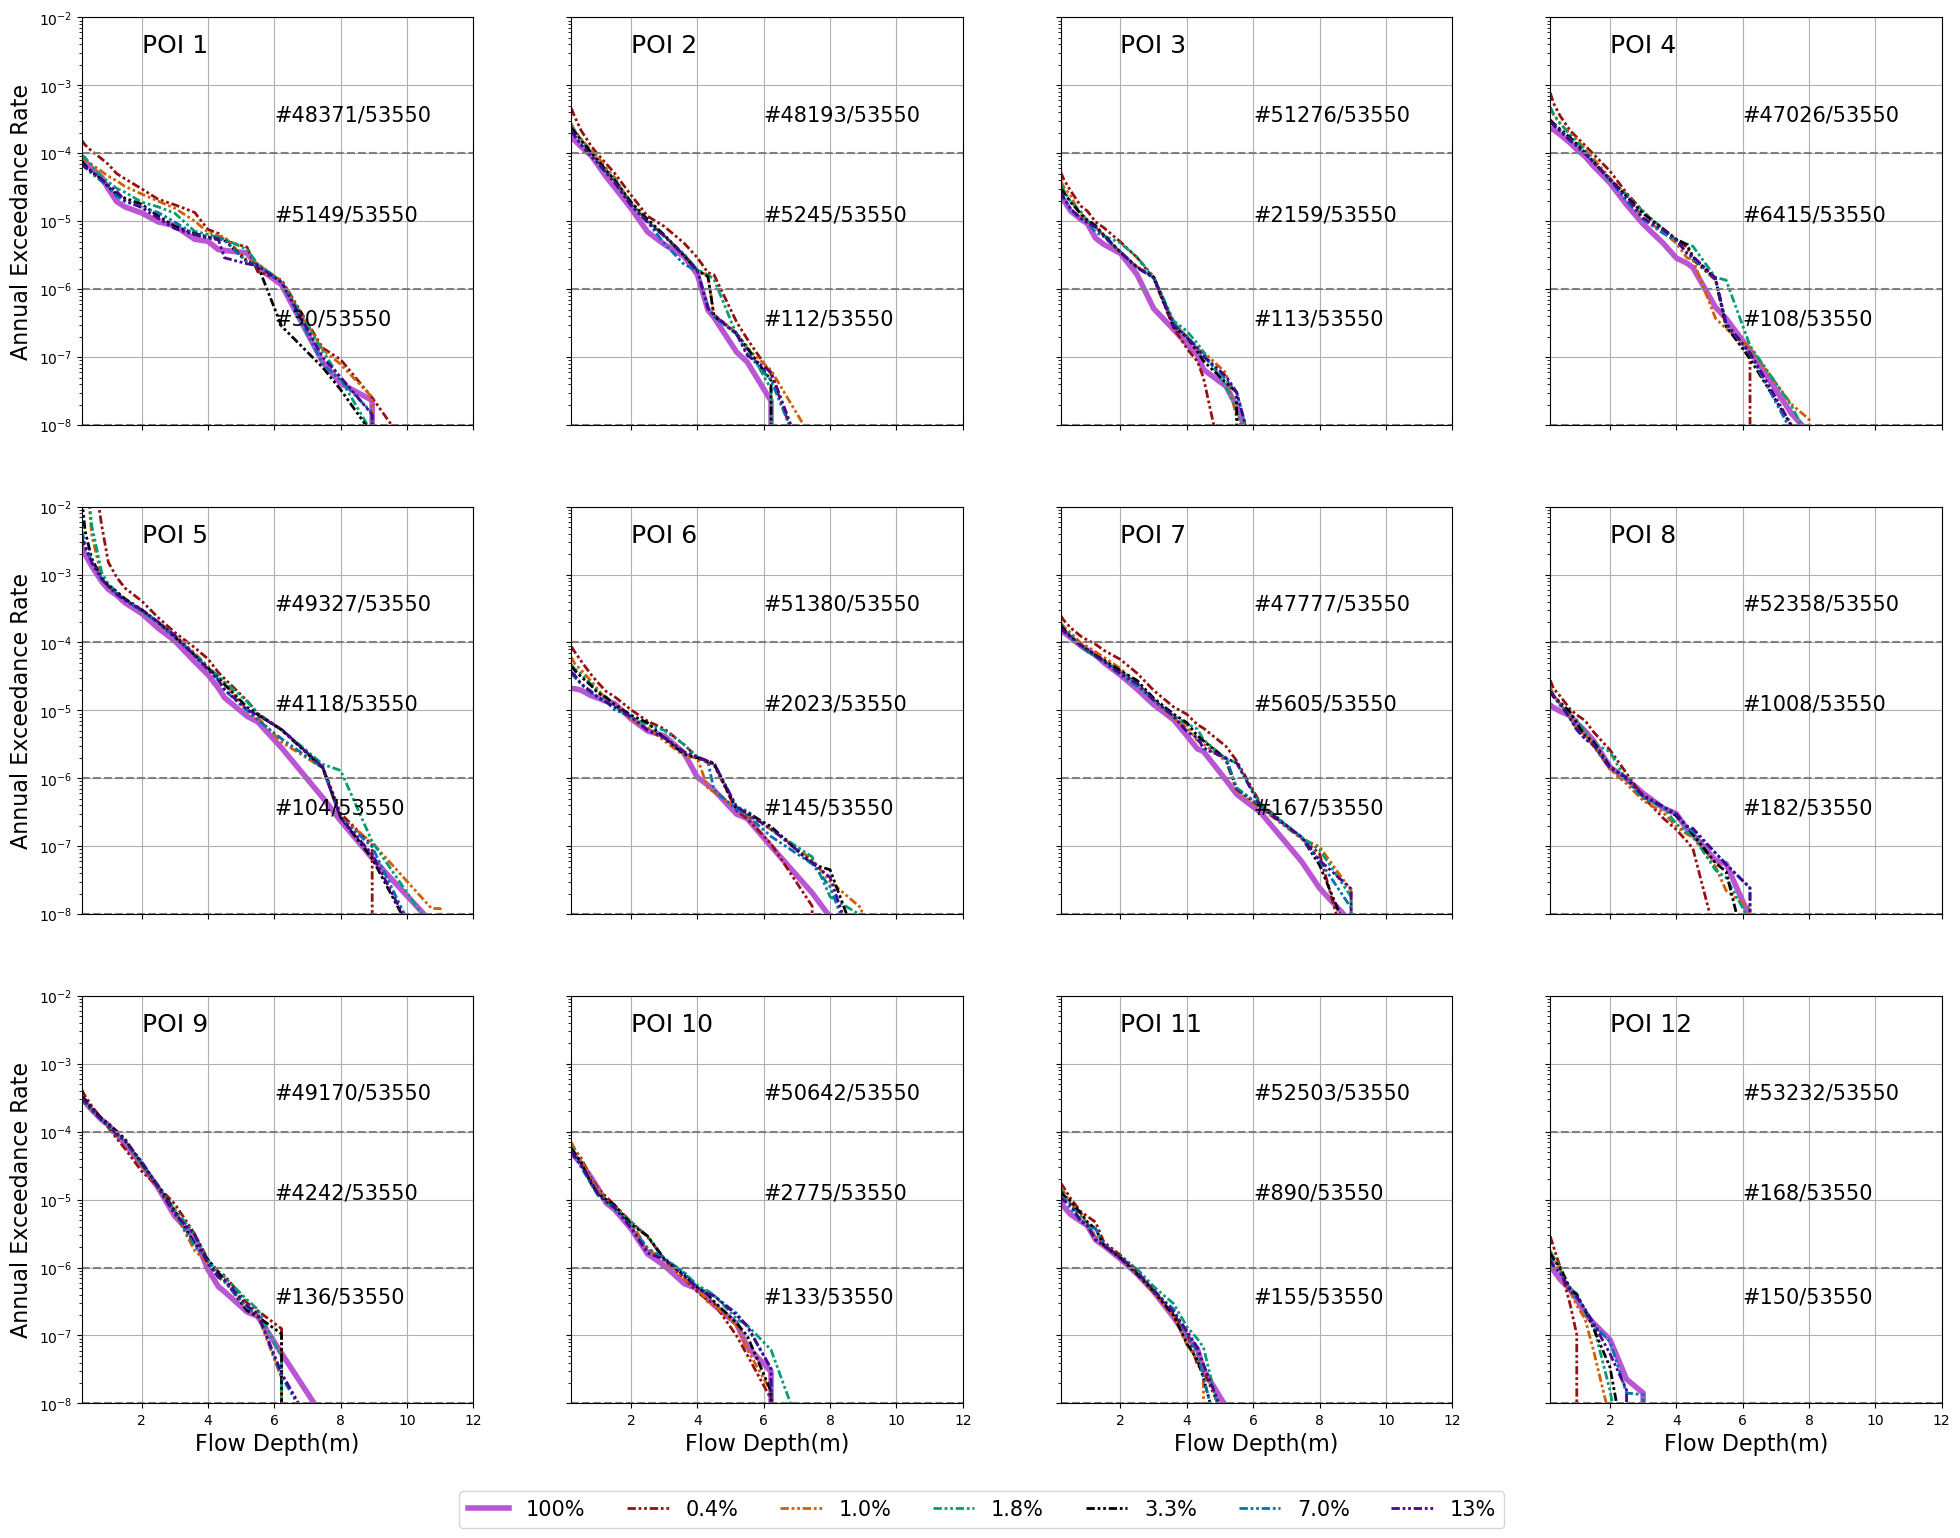

In [10]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')
eve_dep_4 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[4]}_true_pred_er_combined.csv')
eve_dep_5 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[5]}_true_pred_er_combined.csv')

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
# thresholds_depth = np.linspace(0.2, 15, num=100)
thresholds_depth = np.array([0.2, 0.3, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0,
                             3.6, 4.0, 4.32, 4.5, 5.18, 5.5, 6.22, 7.46, 8.0,
                             8.95, 10.74, 11.0, 12.89])

t = [1e-4,1e-6,1e-8]

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0] #get index of depths that exceed threshold probability
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0] #get number of events that exceed threshold depth and set probability
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

# Initialize a figure with 12 subplots (3 rows, 4 columns)
fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.2, wspace=0.25)  # Adjust space between subplots

#set font size as 15
plt.rcParams.update({'font.size': 15})

# Iterate over points
for idx, select_pt in enumerate(range(1, 13)):  # Loop through POIs 1 to 12
    select_pt = str(select_pt)
    
    # True and predicted values
    true = eve_dep_0['T' + select_pt].values
    pred_0 = eve_dep_0['P' + select_pt].values
    pred_1 = eve_dep_1['P' + select_pt].values
    pred_2 = eve_dep_2['P' + select_pt].values
    pred_3 = eve_dep_3['P' + select_pt].values
    pred_4 = eve_dep_4['P' + select_pt].values
    pred_5 = eve_dep_5['P' + select_pt].values

    # Compute exceedance curves
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_curve(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_curve(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_curve(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_curve(thresholds_depth, pred_3, rate)
    lambda_exc_pred_4 = single_exceedance_curve(thresholds_depth, pred_4, rate)
    lambda_exc_pred_5 = single_exceedance_curve(thresholds_depth, pred_5, rate)

    # Get subplot position
    row, col = divmod(idx, 4)
    ax = axes[row, col]
    
    # Plot exceedance curves
    ax.plot(thresholds_depth, lambda_exc_true, label='100%', color='mediumorchid', linewidth=4)
    ax.plot(thresholds_depth, lambda_exc_pred_0, label=labels[0], color=colors[0], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_1, label=labels[1], color=colors[1], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_2, label=labels[2], color=colors[2], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_3, label=labels[3], color=colors[3], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_4, label=labels[4], color=colors[4], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_5, label=labels[5], color=colors[5], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))

    
    # Add horizontal lines for threshold probabilities
    for thresh in t:
        ax.axhline(y=thresh, color='grey', linestyle='--')
    
    # Add number of events exceeding thresholds
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true, t)
    ax.text(6, 3 * (1e-4), f'#{eve_dep_0.shape[0] - sum(ncount)}/{eve_dep_0.shape[0]}', color='k')
    ax.text(6, 1e-5, f'#{ncount[0]}/{eve_dep_0.shape[0]}', color='k')
    ax.text(6, 3 * (1e-7), f'#{ncount[1]}/{eve_dep_0.shape[0]}', color='k')
    
    # Set subplot title and axis labels
    ax.text(2,3 * (1e-3),f'POI {select_pt}',fontsize=18)
    if row == 2:
        ax.set_xlabel('Flow Depth(m)', fontsize=16)
    if col == 0:
        ax.set_ylabel('Annual Exceedance Rate', fontsize=16)

    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlim(0.2, 12)
    ax.set_ylim(1e-8, 1e-2)
 
# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=7,              # Number of columns in the legend
    bbox_to_anchor=(0.5, 0.035),  # Move legend closer to the subplots
)

# Save and display the figure
plt.savefig(f'./hazardcurve_exceedance_allsites_{reg}.png', dpi=300, bbox_inches='tight')
plt.show()


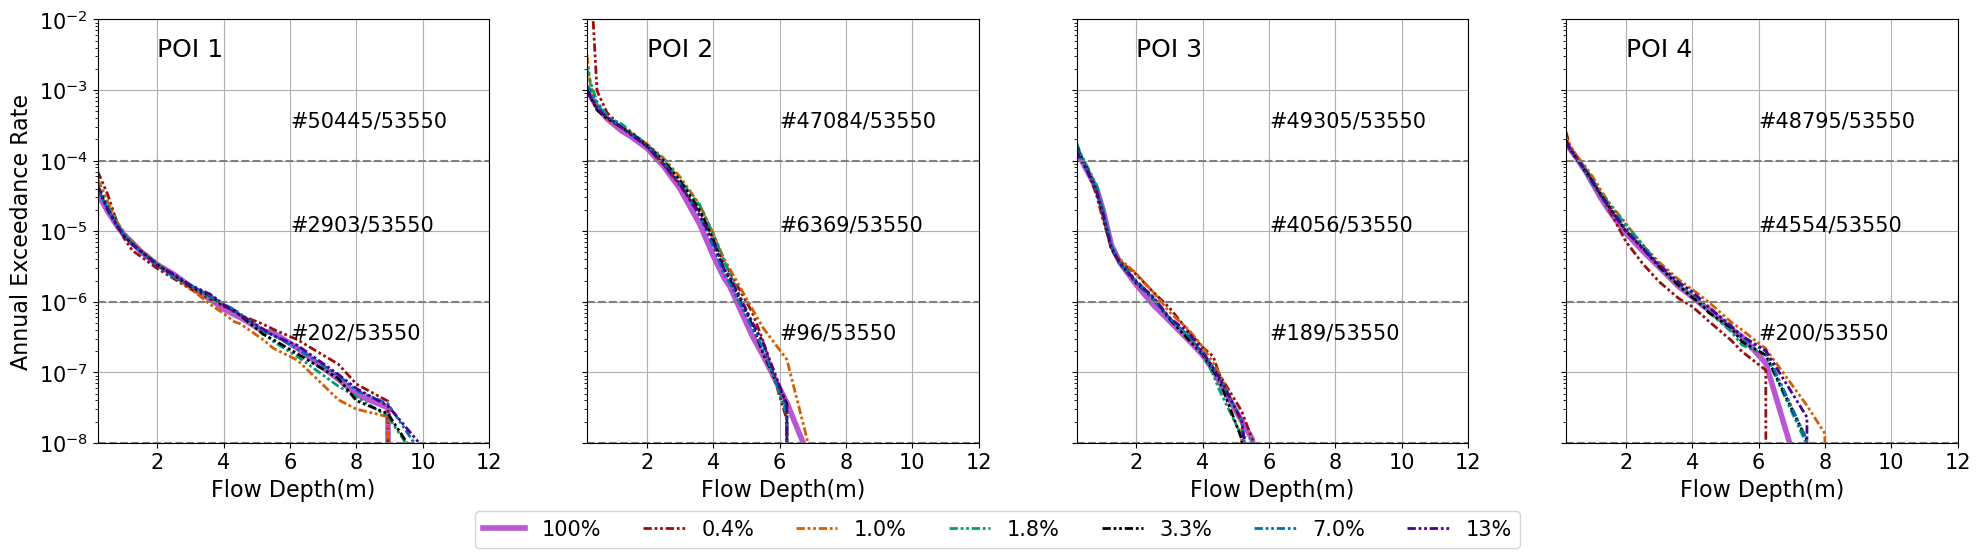

In [16]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

eve_dep_0 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_combined.csv')
eve_dep_1 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[1]}_true_pred_er_combined.csv')
eve_dep_2 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[2]}_true_pred_er_combined.csv')
eve_dep_3 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[3]}_true_pred_er_combined.csv')
eve_dep_4 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[4]}_true_pred_er_combined.csv')
eve_dep_5 = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[5]}_true_pred_er_combined.csv')

#set depth thresholds
# thresholds_depth = [0.2,0.5,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
# thresholds_depth = np.linspace(0.2, 15, num=100)
thresholds_depth = np.array([0.2, 0.3, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0,
                             3.6, 4.0, 4.32, 4.5, 5.18, 5.5, 6.22, 7.46, 8.0,
                             8.95, 10.74, 11.0, 12.89])

t = [1e-4,1e-6,1e-8]

colors = [
    "#971010", 
    "#d55e00", 
    "#009e73", 
    "#000000",  
    "#0072b2",
    "#4b0092",  
    "#e69f00"   
    ]

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

def exceedance_count(true, thresholds_depth, lambda_exc_true, t = [1e-4,1e-6,1e-8]):
    ncount = []
    for i in range(len(t)):
        depth_idx = np.where(lambda_exc_true < t[i])[0] #get index of depths that exceed threshold probability
        n = true[true > thresholds_depth[depth_idx[0]]].shape[0] #get number of events that exceed threshold depth and set probability
        ncount.append(n)
    ncount[1] = ncount[1] - ncount[2]
    return ncount

# Initialize a figure with 4 subplots (1 rows, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.2, wspace=0.25)  # Adjust space between subplots

#set font size as 15
plt.rcParams.update({'font.size': 15})

# Iterate over points
for idx, select_pt in enumerate(range(1, 5)):  # Loop through POIs 1 to 12
    select_pt = str(select_pt)
    
    # True and predicted values
    true = eve_dep_0['T' + select_pt].values
    pred_0 = eve_dep_0['P' + select_pt].values
    pred_1 = eve_dep_1['P' + select_pt].values
    pred_2 = eve_dep_2['P' + select_pt].values
    pred_3 = eve_dep_3['P' + select_pt].values
    pred_4 = eve_dep_4['P' + select_pt].values
    pred_5 = eve_dep_5['P' + select_pt].values

    # Compute exceedance curves
    lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
    lambda_exc_pred_0 = single_exceedance_curve(thresholds_depth, pred_0, rate)
    lambda_exc_pred_1 = single_exceedance_curve(thresholds_depth, pred_1, rate)
    lambda_exc_pred_2 = single_exceedance_curve(thresholds_depth, pred_2, rate)
    lambda_exc_pred_3 = single_exceedance_curve(thresholds_depth, pred_3, rate)
    lambda_exc_pred_4 = single_exceedance_curve(thresholds_depth, pred_4, rate)
    lambda_exc_pred_5 = single_exceedance_curve(thresholds_depth, pred_5, rate)

    # Get subplot position
    ax = axes[idx]
    
    # Plot exceedance curves
    ax.plot(thresholds_depth, lambda_exc_true, label='100%', color='mediumorchid', linewidth=4)
    ax.plot(thresholds_depth, lambda_exc_pred_0, label=labels[0], color=colors[0], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_1, label=labels[1], color=colors[1], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_2, label=labels[2], color=colors[2], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_3, label=labels[3], color=colors[3], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_4, label=labels[4], color=colors[4], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))
    ax.plot(thresholds_depth, lambda_exc_pred_5, label=labels[5], color=colors[5], linewidth=2,linestyle=(0, (3, 1, 1, 1, 1, 1)))

    
    # Add horizontal lines for threshold probabilities
    for thresh in t:
        ax.axhline(y=thresh, color='grey', linestyle='--')
    
    # Add number of events exceeding thresholds
    ncount = exceedance_count(true, thresholds_depth, lambda_exc_true, t)
    ax.text(6, 3 * (1e-4), f'#{eve_dep_0.shape[0] - sum(ncount)}/{eve_dep_0.shape[0]}', color='k')
    ax.text(6, 1e-5, f'#{ncount[0]}/{eve_dep_0.shape[0]}', color='k')
    ax.text(6, 3 * (1e-7), f'#{ncount[1]}/{eve_dep_0.shape[0]}', color='k')
    
    # Set subplot title and axis labels
    ax.text(2,3 * (1e-3),f'POI {select_pt}',fontsize=18)
    ax.set_xlabel('Flow Depth(m)', fontsize=16)
    if idx == 0:
        ax.set_ylabel('Annual Exceedance Rate', fontsize=16)

    ax.set_yscale('log')
    ax.grid(True)
    ax.set_xlim(0.2, 12)
    ax.set_ylim(1e-8, 1e-2)

    
# Adjust the legend position
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center',  # Position the legend below the subplots
    ncol=7,              # Number of columns in the legend
    bbox_to_anchor=(0.5,- 0.1),  # Move legend closer to the subplots
)

# Save and display the figure
plt.savefig(f'./hazardcurve_exceedance_allsites_{reg}.png',bbox_inches='tight',dpi=300)
plt.show()
 